# Classical Shadows for a Two-Qubit Ising (ZZ) Time Evolution

This is a companion notebook for the Qurrium paper's classical-shadow demonstrations. It processes real hardware data (device called "AS QPU" in the
paper) alongside a noiseless simulation ("ideal") for a 2-qubit system evolving under a pure $J\,Z\otimes Z$ Ising interaction. The dynamics is digitized into 25 time steps
(`time_step` = time step index) using a circuit that exactly simulates
$e^{-iJZZt}$ with no Trotter approximation. The measurement data is saved in Qurrium's data format and provided in a separate subdirectory. At each time step we:

1. Load 90 classical-shadow snapshots (from $N_U$ randomly chosen single-qubit bases) for both the AS QPU and the ideal simulator.
2. Estimate purities, two-qubit Pauli expectation values, and state overlaps using `qurry.process.classical_shadow`.
3. Compare hardware results against the ideal simulation and an analytic prediction.


## Setup

We import `qurry`'s classical-shadow processing functions directly (rather than
the `ShadowUnveil` experiment manager used in `ex1-cluster-state.ipynb`),
since here we're post-processing externally-saved counts/basis data rather than running the full experiment.

In [1]:
from qurry import __version__, EntropyMeasure
print("| Using qurrium version:", __version__)

| Using qurrium version: 1.0.0.dev5


/Users/anaball/miniconda3/envs/qurv1dev5/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from qurry.process.classical_shadow import classical_shadow_complex 


 We will use `expectation_from_rho(mean_of_rho, operators)`, a small helper in this notebook to compute expectation values of given operators. This helper function returns linear overlap when the given observable is the density matrix of a known state.  

The input argument of this helper function is a shadow-estimated density matrix (`mean_of_rho`, the first element of `classical_shadow_complex`'s return tuple). It computes $\mathrm{Tr}(\rho O)$ directly for a list of operators. 

In [23]:
def expectation_from_rho(mean_of_rho, operators):
    """Compute Tr(rho @ O) for each operator O using mean_of_rho from ClassicalShadowBasic.

    Args:
        mean_of_rho: basic['mean_of_rho'] where basic = classical_shadow_complex(...)[0]
        operators:   list of numpy arrays, each (2^k x 2^k)

    Returns:
        list of complex128 expectation values
    """
    rho = np.array(mean_of_rho, dtype='complex128')
    return [np.trace(rho @ np.array(op, dtype='complex128')) for op in operators]

## Measurement data

In the subdirectory, `./ASQ_data`, there are 25 json files that store data from AS QPU and ideal simulations. The data format is explained below.

### Data format

Each file `results.angle_{t}_of_24.qubits_1_2.ZZ.json` holds one time step.
The filename encodes three tags that also appear as the `category` field inside the file:
- **`angle_{t}_of_24`** — time-step index $t \in \{0,\dots,24\}$, corresponding to $Jt = t\pi/24$.
- **`qubits_1_2`** — the two physical qubit labels on the device.
- **`ZZ`** — the circuit name (exact $e^{-iJZZt}$ implemented with two CX gates).

The file has the following top-level keys:

| Key | Description |
|---|---|
| `results` | 90-snapshot QPU data (list of `[counts, basis]` pairs) |
| `ideal_results` | 90-snapshot noiseless-simulator data (same structure, but probabilities instead of integer counts) |
| `category` | List of tag strings mirroring the filename |
| `config` | Experiment configuration: `shadow_size` (90 snapshots), `shots_per_snapshot` (32), and hardware calibration data |
| `taking_time` | Wall-clock QPU job time in seconds |
| `datatimes` | Timestamps for job submission and retrieval |
| `circuit` | Serialized circuit definition |

**For each snapshot:** Each element of `results` (and `ideal_results`) is a two-element list `[counts, basis]`:
- **`counts`** — a dict mapping 2-bit bitstring → measurement count.  
  For QPU data the values are integers summing to 32 (= `shots_per_snapshot`), e.g. `{'00': 27, '01': 2, '10': 3, '11': 0}`.  
  For ideal data the values are floating-point Born-rule probabilities summing to 1, e.g. `{'00': 1.0, '01': ~0, '10': ~0, '11': ~0}` — the notebook rescales them with `round(v * 32)` before passing to `classical_shadow_complex`.
- **`basis`** — a list of two integers, one per qubit, encoding the randomly chosen single-qubit Pauli measurement basis: `0` = X, `1` = Y, `2` = Z.  
  Across the 90 snapshots all $3^2 = 9$ basis combinations appear exactly 10 times each, giving even Pauli coverage.


## Purity and observable expectation values across the time evolution

For each of the 25 time steps (`time_step`), load the corresponding JSON file: 90 classical-shadow snapshots for both the real-device run (`results`) and the noiseless-simulator run (`ideal_results`). For each, `classical_shadow_complex(...)`, returning `(basic, purity, estimation)`, is called for each system of interest, qubit 0 alone, qubit 1 alone, and both qubits jointly. The joint call also passes `given_operators=given_ops`, the six two-qubit Pauli operators $I_0X_1, X_0I_1, X_0X_1, I_0Y_1, Y_0I_1, Y_0Y_1$, to get shadow-estimated expectation values directly.

In [4]:

dirn='./ASQ_data/'


def run_csc(counts, u_array):
    csc0   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0])
    csc1   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[1])
    cscall = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0,1], given_operators=given_ops)
    return csc0[1]["purity"], csc1[1]["purity"], cscall[1]["purity"], cscall[2]["estimate_of_given_operators"]

q0angle, q1angle, qsangle, exps = [], [], [], []
ideal_q0angle, ideal_q1angle, ideal_qsangle, ideal_exps = [], [], [], []

for time_step in range(25):
    fn = dirn + "results.angle_{}_of_24.qubits_1_2.ZZ.json".format(time_step)
    with open(fn, "r") as file:
        data = json.load(file)

    expcount   = [data["results"][i][0] for i in range(90)]
    expu       = [data["results"][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data["ideal_results"][i][0].items()} for i in range(90)]
    idealu     = [data["ideal_results"][i][1] for i in range(90)]

    q0a,  q1a,  qsa,  exp_val  = run_csc(expcount,   expu)
    iq0a, iq1a, iqsa, iexp_val = run_csc(idealcount, idealu)

    q0angle.append(q0a);         q1angle.append(q1a);         qsangle.append(qsa);         exps.append(exp_val)
    ideal_q0angle.append(iq0a);  ideal_q1angle.append(iq1a);  ideal_qsangle.append(iqsa);  ideal_exps.append(iexp_val)

exps       = np.array(exps)
ideal_exps = np.array(ideal_exps)


### Figure: single- and two-qubit purity vs. time

Panel (a): single-qubit purities $\hat p_2$ for $q_0$ and $q_1$ against the analytic prediction — under $ZZ$ Ising evolution starting from a product state, each qubit's reduced state becomes mixed as entanglement builds up, so purity dips below 1. Panel (b): the 2-qubit purity $q_0 q_1$, which noiseless unitary evolution keeps at 1 exactly (the *ideal* markers should sit at 1 throughout). 

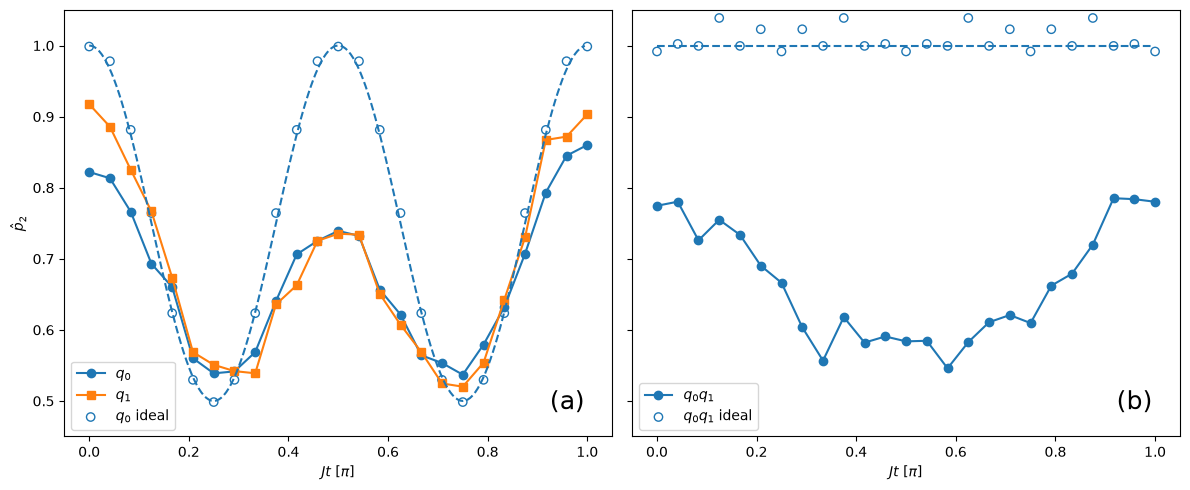

In [5]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
yticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: purity of q_0
ax1.plot(ts, q0angle,          label=r'$q_0$',           linestyle='-',  marker='o')
ax1.plot(ts, q1angle,          label=r'$q_1$',           linestyle='-',  marker='s')
ax1.plot(manyt, 1-2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_q0angle, label=r'$q_0$ ideal',     facecolors='none', edgecolors='C0', marker='o')
#ax1.plot(ts, mitigated_q0angle, label=r'$q_0$ mitigated', color='C2', linestyle='-.', marker='^')
#ax1.plot(ts, mitigated_q1angle, label=r'$q_1$ mitigated', color='C1', linestyle='-.', marker='v')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{p}_2$')
ax1.set_ylim(0.45, 1.05)
ax1.set_yticks(yticks)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: purity of q_0 q_1
ax2.plot(ts, qsangle,          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, ideal_qsangle, label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylim(0.45, 1.05)
ax2.set_yticks(yticks)
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()


### Figure: 2nd-order Rényi entropy vs. time

Same purities as above, converted to entropy via $S^{(2)} = -\log_2(\hat{p}_2)$: panel (a) single-qubit entanglement entropy growth for $q_0$, $q_1$; panel (b) the full system's entropy, which should stay at 0 for a noiseless pure-state evolution. 

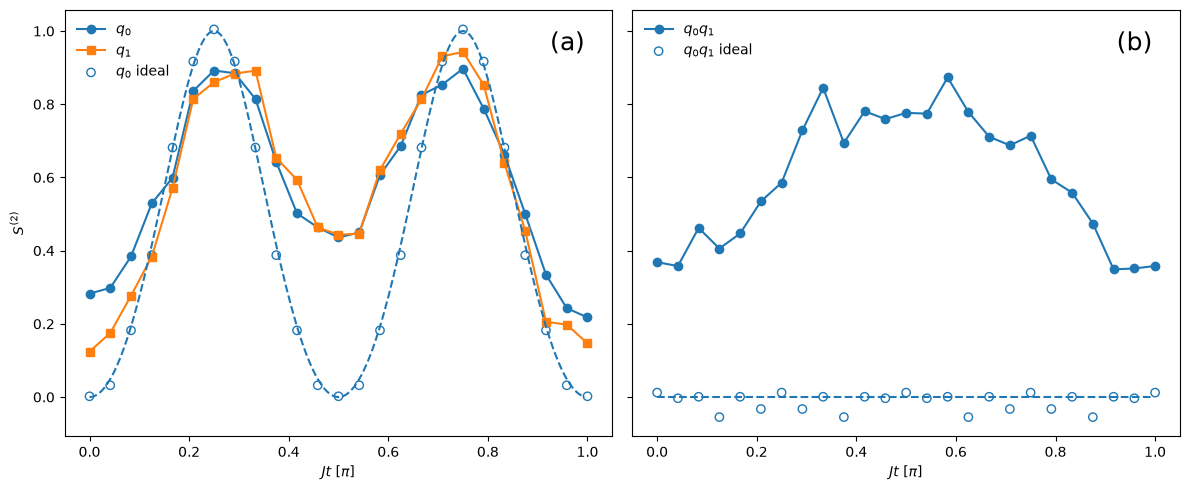

In [6]:
ts    = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: S_2 of q_0, q_1
ax1.plot(ts, -np.log2(q0angle),          label=r'$q_0$',       linestyle='-',  marker='o')
ax1.plot(ts, -np.log2(q1angle),          label=r'$q_1$',       linestyle='-',  marker='s')
ax1.plot(manyt, -np.log2(1 - 2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2), linestyle='--', color='C0')
ax1.scatter(ts, -np.log2(ideal_q0angle), label=r'$q_0$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$S^{(2)}$')
ax1.legend(loc='best',frameon=False)
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, ha='right', va='top', fontsize=18)

# Right: S_2 of q_0 q_1
ax2.plot(ts, -np.log2(qsangle),          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, -np.log2(ideal_qsangle), label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt, np.zeros(manyt.shape),   linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='upper left',frameon=False)
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, ha='right', va='top', fontsize=18)

fig.tight_layout()
plt.show()


### Expectation values from the reconstructed density matrix

The following cell computes the six two-qubit Pauli expectation values by reconstructing the full shadow-estimated density matrix `mean_of_rho` and taking $\mathrm{Tr}(\rho O)$ directly with `expectation_from_rho`, for both QPU and ideal data at every time step.

In [75]:
# Computes expectation values of two-qubit Pauli operators (XI, IX, XX, YI, IY, YY)
# from the classical shadow estimated state rho(t), for both experimental and ideal data.
I2 = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Y = np.array([[0, -1.j], [1.j, 0]])
Z = np.array([[1, 0], [0, -1]])

given_ops = [np.kron(X,I2), np.kron(I2,X), np.kron(X,X),
             np.kron(Y,I2), np.kron(I2,Y), np.kron(Y,Y)]
exps_rho = []
ideal_exps_rho = []

for time_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.ZZ.json'.format(time_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, exps = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1],given_operators=given_ops)
    ideal_basic, _, ideal_exps = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1],given_operators=given_ops)

    
    exps_rho.append(expectation_from_rho(basic['mean_of_rho'], given_ops))
    ideal_exps_rho.append(expectation_from_rho(ideal_basic['mean_of_rho'], given_ops))
exps_rho       = np.array(exps_rho).real
ideal_exps_rho = np.array(ideal_exps_rho).real

### Figure: two-qubit Pauli correlations vs. time

Shadow-estimated expectation values (via the `expectation_from_rho` cross-check route) of $I_0X_1$, $X_0X_1$ in panel (a) and $I_0Y_1$, $Y_0Y_1$ in panel (b), for QPU vs. ideal data, overlaid with their analytic predictions under the pure $J\,Z\otimes Z$ evolution. 

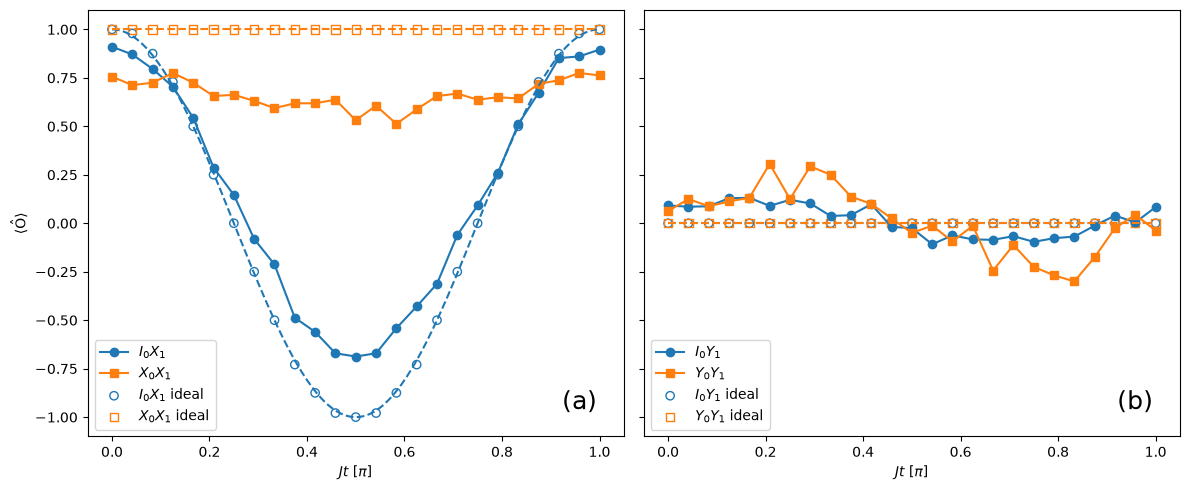

In [76]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: X components
ax1.plot(ts, exps_rho[:,0],      label=r'$I_0X_1$', linestyle='-', marker='o')
ax1.plot(ts, exps_rho[:,2],      label=r'$X_0X_1$', linestyle='-', marker='s')
ax1.plot(manyt, np.cos(manyt*np.pi*2), linestyle='--', color='C0')
ax1.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C1')
ax1.scatter(ts, ideal_exps_rho[:,0], label=r'$I_0X_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.scatter(ts, ideal_exps_rho[:,2], label=r'$X_0X_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\langle\hat{\mathsf{O}}\rangle$')
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: Y components
ax2.plot(ts, exps_rho[:,3],      label=r'$I_0Y_1$', linestyle='-', marker='o')
ax2.plot(ts, exps_rho[:,5],      label=r'$Y_0Y_1$', linestyle='-', marker='s')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C0')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C1')
ax2.scatter(ts, ideal_exps_rho[:,3], label=r'$I_0Y_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.scatter(ts, ideal_exps_rho[:,5], label=r'$Y_0Y_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()


### State overlap with the initial state

Two independent ways to estimate the overlap between the all-plus initial state $\rho_0 = |{+}{+}\rangle\langle{+}{+}|$ and the shadow-estimated state $\rho(t)$ at each time step:

- **Linear overlap** `linoverlap` $= \mathrm{Tr}(\rho_0\,\rho(t))$, computed directly from the averaged shadow `mean_of_rho`, which is valid here because $\rho_0$ is a *known, fixed* product state, exactly as in ex1's linear-overlap section.
- **Nonlinear overlap** `overlap` uses the `projector` estimator from ex1's nonlinear-overlap section. Here the "reference" state's per-snapshot projector (`proj_c_list`) is taken from this same experiment's own $t{=}0$ data (`time_step == 0`) rather than from an analytic density matrix. The projector is then reused as the fixed reference for every later time step. This demonstrates the general-purpose nonlinear estimator on real data, without assuming the initial state is known analytically.

In [77]:
def get_projector(expcount,expu,idealcount,idealu):
    # To compute the overlap using the nonlinear functional
    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='multi_shots',trace_method="skip_trace",use_projecter=True)
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='multi_shots',trace_method="skip_trace",use_projecter=True)
    proj_c_list       = np.array(basic['average_snapshots_rho_list'],       dtype='complex128')
    ideal_proj_c_list = np.array(ideal_basic['average_snapshots_rho_list'], dtype='complex128')
    return proj_c_list, ideal_proj_c_list

In [78]:
# Computes the linear overlap Tr(rho0 @ rho(t)) between the initial state rho0
# and the shadow-estimated state rho(t) at each time step, for both experimental and ideal data.
psi = np.ones(2**2, dtype='complex128') / np.sqrt(2**2)
rho0 = np.outer(psi, psi.conj())
linoverlap = []
ideal_linoverlap = []
overlap = []
ideal_overlap = []
rho_c_list = None
ideal_rho_c_list = None

for time_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.ZZ.json'.format(time_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='multi_shots',trace_method="skip_trace")
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='multi_shots',trace_method="skip_trace")

    linoverlap.append(np.trace(rho0 @ np.array(basic['mean_of_rho'], dtype='complex128')))
    ideal_linoverlap.append(np.trace(rho0 @ np.array(ideal_basic['mean_of_rho'], dtype='complex128')))

    
    rho_m_list       = np.array(basic['average_snapshots_rho_list'],       dtype='complex128')
    ideal_rho_m_list = np.array(ideal_basic['average_snapshots_rho_list'], dtype='complex128')
    Nu = len(rho_m_list)

    if time_step == 0:
        proj_c_list,ideal_proj_c_list=get_projector(expcount,expu,idealcount,idealu)
    trclusterrho       = np.einsum('nij,nji->n', proj_c_list,       rho_m_list)
    ideal_trclusterrho = np.einsum('nij,nji->n', ideal_proj_c_list, ideal_rho_m_list)
    overlap.append(trclusterrho.sum() / Nu)
    ideal_overlap.append(ideal_trclusterrho.sum() / Nu)

linoverlap       = np.array(linoverlap).real
ideal_linoverlap = np.array(ideal_linoverlap).real
overlap          = np.array(overlap).real
ideal_overlap    = np.array(ideal_overlap).real

### Figure: state overlap vs. time

Two-panel comparison of the overlap estimates above against the pure-$ZZ$-Ising analytic prediction $\cos^2(J t)$ (dashed): panel (a) the linear overlap `linoverlap`/`ideal_linoverlap`, panel (b) the cross-shadow overlap `overlap`/`ideal_overlap`, both for QPU (solid, real hardware) and ideal (open markers, noiseless simulation). 

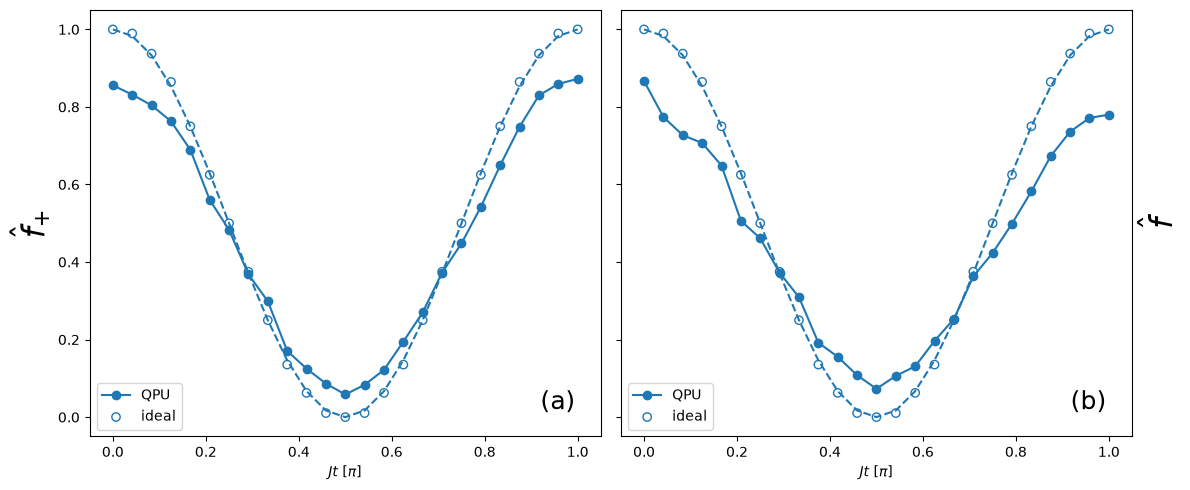

In [32]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: linear overlap Tr(rho0 @ rho(t))
ax1.plot(ts, linoverlap,          label=r'QPU',   linestyle='-', marker='o')
ax1.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_linoverlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{f}_{+}$', fontsize=22)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: overlap
ax2.plot(ts, overlap,          label=r'QPU',   linestyle='-', marker='o')
ax2.scatter(ts, ideal_overlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylabel(r'$\hat{f}$', fontsize=22)
ax2.yaxis.set_label_position('right')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.show()


**AI usage disclosure**
AI assistance was used for code and markdown explanations, under author guidance, and was verified by the authors.